<a href="https://colab.research.google.com/github/minbj1226/pytorch-basics/blob/main/05_Train_Eval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. model.train()은 무엇인가?
- 모델을 학습 모드로 전환하는 것

### 2. model.eval()은 무엇인가?
- 모델을 평가모드로 전환하는 것

### 3. train 모드와 eval 모드의 차이는 무엇인가?
- train 모드와 eval 모드의 가장 큰 차이는 Dropout, BatchNorm 같은 일부 레이어의 동작 방식이 달라진다는 점

### 4. torch.no_grad() 사용 이유
- 평가 단계에서는 gradient 계산이 필요 없으므로 torch.no_grad()를 사용하여 메모리 사용량을 줄이고 연산 속도를 높인다

### 5. Dropout과 BatchNorm이 train/eval 구분이 필요한 이유
- Dropout과 BatchNorm은 학습 시와 평가 시 동작 방식이 다르기 때문에 train 모드와 eval 모드를 구분해야 한다

In [ ]:
import torch
import torchvision
from torchvision.transforms import v2

from torch.utils.tensorboard import SummaryWriter
from datetime import datetime

transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5,), (0.5,))
])

training_set = torchvision.datasets.FashionMNIST('./data', train=True, transform=transform, download=True)
validation_set = torchvision.datasets.FashionMNIST('./data', train=False, transform=transform, download=True)

training_loader = torch.utils.data.DataLoader(training_set, batch_size=4, shuffle=True)
validation_loader = torch.utils.data.DataLoader(validation_set, batch_size=4, shuffle=False)

classes = ('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
        'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot')

print(f'Training set has {len(training_set)} instances')
print(f'Validation set has {len(validation_set)} instances')

100%|██████████| 26.4M/26.4M [00:01<00:00, 20.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 300kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.52MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 18.7MB/s]

Training set has 60000 instances
Validation set has 10000 instances


Trouser  Coat  Sneaker  Dress


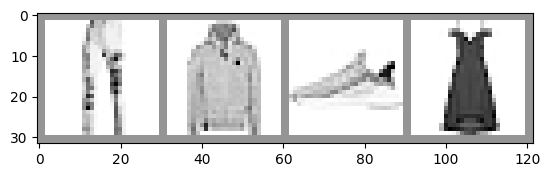

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def matplotlib_imshow(img, one_channel=False):
  if one_channel:
    img = img.mean(dim=0)
  img = img / 2 + 0.5
  npimg = img.numpy()
  if one_channel:
    plt.imshow(npimg, cmap="Greys")
  else:
    plt.imshow(np.transpose(npimg, (1, 2, 0)))

dataiter = iter(training_loader)
images, labels = next(dataiter)

img_grid = torchvision.utils.make_grid(images)
matplotlib_imshow(img_grid, one_channel=True)
print('  '.join(classes[labels[j]] for j in range(4)))

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class GarmentClassifier(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(1, 6, 5)
    self.pool = nn.MaxPool2d(2, 2)
    self.conv2 = nn.Conv2d(6, 16, 5)
    self.fc1 = nn.Linear(16 * 4 * 4, 120)
    self.fc2 = nn.Linear(120, 84)
    self.fc3 = nn.Linear(84, 10)

  def forward(self, x):
    x = self.pool(F.relu(self.conv1(x)))
    x = self.pool(F.relu(self.conv2(x)))
    x = x.view(-1, 16 * 4 * 4)
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.fc3(x)
    return x

model = GarmentClassifier()

In [ ]:
loss_fn = torch.nn.CrossEntropyLoss()

dummy_outputs = torch.rand(4, 10)
dummy_labels = torch.tensor([1, 5, 3, 7])

print(dummy_outputs)
print(dummy_labels)

loss = loss_fn(dummy_outputs, dummy_labels)
print(f'Total loss for this batch: {loss.item()}')

tensor([[0.2682, 0.7106, 0.8790, 0.8728, 0.3077, 0.8479, 0.7890, 0.0491, 0.7537,
         0.7945],
        [0.3676, 0.3157, 0.9979, 0.6888, 0.1917, 0.4872, 0.9699, 0.7072, 0.3985,
         0.6144],
        [0.6765, 0.2950, 0.8965, 0.8724, 0.0441, 0.0411, 0.3740, 0.2455, 0.9265,
         0.5503],
        [0.6517, 0.3433, 0.6804, 0.0339, 0.1849, 0.5734, 0.1469, 0.5166, 0.8249,
         0.9258]])
tensor([1, 5, 3, 7])
Total loss for this batch: 2.2419252395629883


In [ ]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

In [ ]:
def train_one_epoch(epoch_index, tb_writer):
  running_loss = 0.
  last_loss = 0.

  for i, data in enumerate(training_loader):
    inputs, labels = data

    #이전 step에서 누적된 grad를 초기화
    optimizer.zero_grad()

    #예측
    output = model(inputs)

    #손실을 기준으로 각 피라미터에 대한 gradient를 계산
    loss = loss_fn(output, labels)
    loss.backward()

    #계산된 gradient를 기반으로 파라미터를 갱신
    optimizer.step()

    running_loss += loss.item()
    if i % 1000 == 999:
      last_loss = running_loss / 1000
      print(f'  batch {i + 1} loss: {last_loss}')
      tb_x = epoch_index * len(training_loader) + i + 1
      tb_writer.add_scalar('Loss/train', last_loss, tb_x)
      running_loss = 0.

  return last_loss

In [ ]:
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
writer = SummaryWriter(f'runs/fashion_trainer_{timestamp}')
epoch_number = 0

EPOCHS = 5

best_vloss = 1_000_000.

for epoch in range(EPOCHS):
  print(f'EPOCH {epoch_number + 1}')
  model.train(True)

  avg_loss = train_one_epoch(epoch_number, writer)

  running_vloss = 0.0
  model.eval()

  with torch.no_grad():
    for i, vdata in enumerate(validation_loader):
      vinputs, vlabels = vdata
      voutputs = model(vinputs)
      vloss = loss_fn(voutputs, vlabels)
      running_vloss += vloss

  avg_vloss = running_vloss / (i + 1)
  print(f'LOSS train {avg_loss}  valid {avg_vloss}')

  writer.add_scalars('Training vs. Validation Loss',
                    { 'Training' : avg_loss, 'Validation' : avg_vloss },
                    epoch_number + 1)
  writer.flush()

  if avg_vloss < best_vloss:
        best_vloss = avg_vloss
        model_path = f'model_{timestamp}_{epoch_number}'
        torch.save(model.state_dict(), model_path)

  epoch_number += 1

EPOCH 1
  batch 1000 loss: 1.8062662692666054
  batch 2000 loss: 0.8718498222976923
  batch 3000 loss: 0.7175786383468657
  batch 4000 loss: 0.6335539828645996
  batch 5000 loss: 0.5744552141791209
  batch 6000 loss: 0.5261740783321147
  batch 7000 loss: 0.5439324966496788
  batch 8000 loss: 0.5184837175495922
  batch 9000 loss: 0.4851135237957351
  batch 10000 loss: 0.46782257037074304
  batch 11000 loss: 0.4690909051930066
  batch 12000 loss: 0.4544300215081894
  batch 13000 loss: 0.4321159703807207
  batch 14000 loss: 0.4170248062006431
  batch 15000 loss: 0.401039816258708
LOSS train 0.401039816258708  valid 0.41925960779190063
EPOCH 2
  batch 1000 loss: 0.4105934014500817
  batch 2000 loss: 0.38573092889151306
  batch 3000 loss: 0.37115510659693973
  batch 4000 loss: 0.38857552517729343
  batch 5000 loss: 0.37158336689902355
  batch 6000 loss: 0.37618195051746445
  batch 7000 loss: 0.3858517895143013
  batch 8000 loss: 0.3608816672177636
  batch 9000 loss: 0.3475561512171989
  bat

In [ ]:
m = nn.Dropout(p=0.2)
input = torch.randn(20, 16)
output = m(input)